In [32]:
from typing import TypedDict,Annotated
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from pydantic import BaseModel ,Field
import operator

In [33]:
model = ChatGoogleGenerativeAI(
    model="models/gemini-3.1-flash-lite",
    temperature=0.2,
    max_output_tokens=256
)

In [34]:
from pydantic import BaseModel, Field


class EvaluationSchema(BaseModel):
    score: int = Field(description="Score out of 10", ge=0, le=10)
    feedback: str = Field(description="Detailed feedback on the essay")

In [35]:
structured_model = model.with_structured_output(EvaluationSchema)

In [36]:
structured_model

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={'name': 'Gemini 3.1 Flash Lite', 'release_date': '2026-05-07', 'last_updated': '2026-05-07', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'minimal'}, google_api_key=SecretStr('**********'), model='models/gemini-3.1-flash-lite', temperature=0.2, max_output_tokens=256, client=<google.genai.client.Client object at

In [37]:
essay = "The impact of climate change on global agriculture is profound. Rising temperatures, changing precipitation patterns, and increased frequency of extreme weather events are affecting crop yields and food security worldwide. Farmers are facing challenges in adapting to these changes, and there is a growing need for sustainable agricultural practices and policies to mitigate the effects of climate change on food production."

In [38]:
prompt=f"Evaluate the language quality of the following essay and provide a score out of 10 along with detailed feedback on the {essay}."

In [39]:
structured_model.invoke(prompt).feedback

'The essay is well-written, concise, and grammatically correct. It effectively introduces the topic and outlines the key challenges associated with climate change and agriculture. The vocabulary is appropriate and professional. To improve, the essay could benefit from more specific examples or a concluding sentence that suggests a path forward or summarizes the urgency of the situation.'

In [40]:
structured_model.invoke(prompt).score

9

In [57]:
class UPSCSTATE(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_scores:Annotated[list[int],operator.add]
    avg_score:float

In [58]:
def evaluate_language(state:UPSCSTATE)->UPSCSTATE:
    prompt=f"Evaluate the language quality of the following essay and provide a feedback and assign a  score out of 10 along with detailed feedback on the {state['essay']}."
    result=structured_model.invoke(prompt)
   
    return {"language_feedback":result.feedback, "individual_scores":[result.score]}

In [59]:
def evaluate_analysis(state:UPSCSTATE)->UPSCSTATE:
    prompt=f"Evaluate the analysis  of the following essay and provide a feedback and assign a  score out of 10 along with detailed feedback on the {state['essay']}."
    result=structured_model.invoke(prompt)
    
    return {"analysis_feedback":result.feedback, "individual_scores":[result.score]}

In [60]:
def evaluate_clarity(state:UPSCSTATE)->UPSCSTATE:
    prompt=f"Evaluate the clarity of the following essay and provide a feedback and assign a  score out of 10 along with detailed feedback on the {state['essay']}."
    result=structured_model.invoke(prompt)
    
    return {"clarity_feedback":result.feedback, "individual_scores":[result.score]   }

In [78]:
def evaluate_overall(state:UPSCSTATE)->UPSCSTATE:
    #summary feedback

    prompt=f"based on the following feedback create a summariezed feedback \n  language feedback {state['language_feedback']} \n analysis feedback {state['analysis_feedback']} \n clarity feedback {state['clarity_feedback']} \n overall feedback  for this essay: {state['essay']}."
    overall_feedback=model.invoke(prompt).content

    #average calculate

    avg_score=sum(state['individual_scores'])/len(state['individual_scores'])


    
    return {"overall_feedback":overall_feedback, "avg_score":avg_score}

In [79]:
graph=StateGraph(UPSCSTATE)
graph.add_node("evaluate_language",evaluate_language)
graph.add_node("evaluate_analysis",evaluate_analysis)
graph.add_node("evaluate_clarity",evaluate_clarity)
graph.add_node("evaluate_overall",evaluate_overall)




graph.add_edge(START,"evaluate_language")
graph.add_edge(START,"evaluate_analysis")
graph.add_edge(START,"evaluate_clarity")


graph.add_edge("evaluate_language","evaluate_overall")
graph.add_edge("evaluate_analysis","evaluate_overall")
graph.add_edge("evaluate_clarity","evaluate_overall")


graph.add_edge("evaluate_overall",END)
workflow=graph.compile()


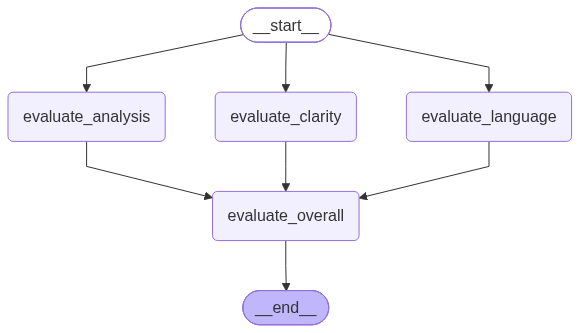

In [80]:
workflow

In [81]:
initial_state = {
    "essay": essay}
final_output=workflow.invoke(initial_state)


In [82]:
final_output

{'essay': 'The impact of climate change on global agriculture is profound. Rising temperatures, changing precipitation patterns, and increased frequency of extreme weather events are affecting crop yields and food security worldwide. Farmers are facing challenges in adapting to these changes, and there is a growing need for sustainable agricultural practices and policies to mitigate the effects of climate change on food production.',
 'language_feedback': 'The essay is clear, concise, and grammatically correct. It effectively summarizes the core issues regarding climate change and agriculture. However, it is quite brief and lacks specific examples or a more nuanced exploration of the topic, which would be necessary for a higher score. The flow is logical, and the vocabulary is appropriate for an academic context.',
 'analysis_feedback': 'The essay provides a clear and accurate overview of the relationship between climate change and agriculture. It correctly identifies key drivers such 

In [75]:
final_output['overall_feedback'][0]['text']

'Here is a summarized version of the feedback for your essay:\n\n**Summary of Feedback**\n\n*   **Strengths:** The essay is well-written, clear, and logically structured. It provides an accurate and concise overview of the core relationship between climate change and agriculture.\n*   **Areas for Improvement:** The content is currently too general and lacks depth. To strengthen the essay, you should:\n    *   **Incorporate Evidence:** Include specific examples, data, or case studies to support your claims.\n    *   **Add Detail:** Expand on how specific regions or crop types are affected.\n    *   **Elaborate on Solutions:** Move beyond vague mentions of "sustainable practices" by discussing specific technologies, agricultural methods, or policy frameworks. \n\n**Overall Verdict:** While the essay is grammatically sound and effectively communicates the main issues, it requires more concrete evidence and detailed analysis to move from a general overview to a persuasive, authoritative ar

In [76]:
final_output['overall_feedback'][0]

{'type': 'text',
 'text': 'Here is a summarized version of the feedback for your essay:\n\n**Summary of Feedback**\n\n*   **Strengths:** The essay is well-written, clear, and logically structured. It provides an accurate and concise overview of the core relationship between climate change and agriculture.\n*   **Areas for Improvement:** The content is currently too general and lacks depth. To strengthen the essay, you should:\n    *   **Incorporate Evidence:** Include specific examples, data, or case studies to support your claims.\n    *   **Add Detail:** Expand on how specific regions or crop types are affected.\n    *   **Elaborate on Solutions:** Move beyond vague mentions of "sustainable practices" by discussing specific technologies, agricultural methods, or policy frameworks. \n\n**Overall Verdict:** While the essay is grammatically sound and effectively communicates the main issues, it requires more concrete evidence and detailed analysis to move from a general overview to a pe